In [1]:
import numpy as np

In [2]:
def generate_data(num_samples=300):
    """
    Generate random XOR data with added noise.
    """
    X = np.random.randn(num_samples, 2)
    y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0)
    noise = np.random.normal(scale=0.01, size=num_samples)
    X = np.concatenate((X, noise.reshape(-1, 1)), axis=1)
    return X, y

1. Generisati skup podataka korišćenjem date funkcije generate_data.

In [3]:
X,y = generate_data()

2. Koliko ima različitih klasa?

In [4]:
#X.shape, y.shape
#np.unique(y) daje niz sa svim jedinstvenim klasama koje postoje
#treba samo naci duzinu tog niza

#np.unique(y).shape ili
len(np.unique(y))

2

3. Ako je potrebno, podeliti skup podataka na deo za obučavanje i deo za testiranje modela.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=67)

4. Da li je skup balansiran? Ako je potrebno, primeniti SMOTE algoritam.

In [6]:
#skup je prilicno balansiran, ne treba SMOTE

np.bincount(y)

array([143, 157])

5. Primeniti SVM algoritam sa linearnim i rbf kernelom za klasifikaciju.

In [7]:
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear')
svm_rbf = SVC(kernel='rbf')

svm_linear.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)

SVC()

6. Uz pomoć PCA algoritma smanjiti dimenzionalnost na 2.

    Koji udeo varijanse je očuvan?
    
    Da li je to očekivano s obzirom na to kako su podaci generisani? 

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

#pca.explained_variance_ratio_

sum(pca.explained_variance_ratio_)

#udeo ocuvane varijanse je 0.999956... sto je ocekivano buduci da je treca dimenzija predstavljala sum nad podacima

0.9999562393991475

7. Nacrtati grafik tako transformisanog skupa – obojiti instance u skladu sa klasom kojom 
    pripadaju, a posebnom bojom označiti potporne vektore.

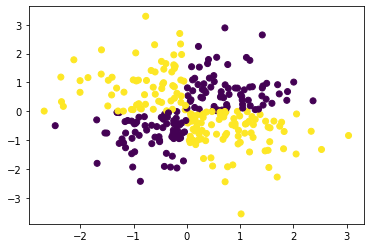

In [9]:
from matplotlib import pyplot as plt

plt.scatter(X[:,0], X[:,1], c=y)

8. Proceniti kvalitet dobijenih modela koristeći matricu konfuzije i tačnost (accuracy) modela.

    Da li je tačnost adekvatna metrika za ovaj skup podataka?
    
    Da li su dobijeni rezultati očekivani s obzirom na svojstva korišćenih kernela i izgled skupa podataka?

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred_lin = svm_linear.predict(X_test)
y_pred_rbf = svm_rbf.predict(X_test)

In [11]:
print(f'Linearni model preciznost: {accuracy_score(y_pred_lin, y_test)}')
print(f'Linearni model matrica konfuzije: \n{confusion_matrix(y_pred_lin, y_test)}')
print(f'RBF model preciznost: {accuracy_score(y_pred_rbf, y_test)}')
print(f'RBF model matrica konfuzije: \n{confusion_matrix(y_pred_rbf, y_test)}')

#RBF model radi bolje jer je granica izmedju klasa nelinearna

Linearni model preciznost: 0.52
Linearni model matrica konfuzije: 
[[ 0  0]
 [36 39]]
RBF model preciznost: 0.8933333333333333
RBF model matrica konfuzije: 
[[29  1]
 [ 7 38]]
